In [1]:
# Librerías necesarias
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display, HTML
import os

# Función para cargar los datos del JSONL
def load_jsonl(file_path):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return data


# Convertir a DataFrame para facilitar el análisis
# Cargar datos
base_df = load_jsonl(file_path='metrics_baseV2.jsonl')  # Usa el archivo .jsonl por defecto
modified_df = load_jsonl(file_path='metrics_modV2.jsonl')  # Usa el archivo .jsonl por defecto

# Convertir a DataFrame
base_df = pd.DataFrame(base_df)
modified_df = pd.DataFrame(modified_df)

C:\Users\cuent\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
print(f"Base DataFrame shape: {base_df.shape}")
print(f"Modified DataFrame shape: {modified_df.shape}")

Base DataFrame shape: (150, 13)
Modified DataFrame shape: (151, 13)


In [3]:
base_df.tail(3)

,step,train_return,train_length,train_total_steps,train_total_episodes,train_loaded_steps,train_loaded_episodes,eval_return,eval_length,eval_total_steps,eval_total_episodes,eval_loaded_steps,eval_loaded_episodes
147,196000,NaN,NaN,NaN,NaN,NaN,NaN,200.0,403.0,25205.0,49.0,953.0,2.0
148,196468,270.0,525.0,49118.0,99.0,9787.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN
149,198268,220.0,450.0,49568.0,100.0,9746.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
#Mostrar el top 10 de eval_return de base df (eval mas altos)
print("Base DataFrame Top 10 eval_return:")
display(base_df[['eval_return', 'eval_length']].nlargest(10, 'eval_return'))

Base DataFrame Top 10 eval_return:


,eval_return,eval_length
85,940.0,1118.0
3,660.0,740.0
89,440.0,820.0
50,420.0,785.0
22,350.0,547.0
53,340.0,553.0
82,330.0,460.0
64,290.0,555.0
110,280.0,484.0
18,270.0,524.0


In [5]:
#Mostrar el top 10 de eval_return de modified df (eval mas altos)
print("Modified DataFrame Top 10 eval_return:")
display(modified_df[['eval_return','eval_length']].nlargest(10, 'eval_return'))

Modified DataFrame Top 10 eval_return:


,eval_return,eval_length
58,740.0,907.0
107,740.0,1042.0
101,690.0,676.0
23,480.0,712.0
86,450.0,617.0
51,360.0,566.0
137,320.0,506.0
67,310.0,500.0
146,290.0,470.0
64,280.0,506.0



Comparativa ajustada entre modelo base y modelo modificado:
--------------------------------------------------
Modelo base: 50 registros, pasos 4,000 a 196,000
Modelo modificado: 50 registros, pasos 4,000 a 196,000


c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


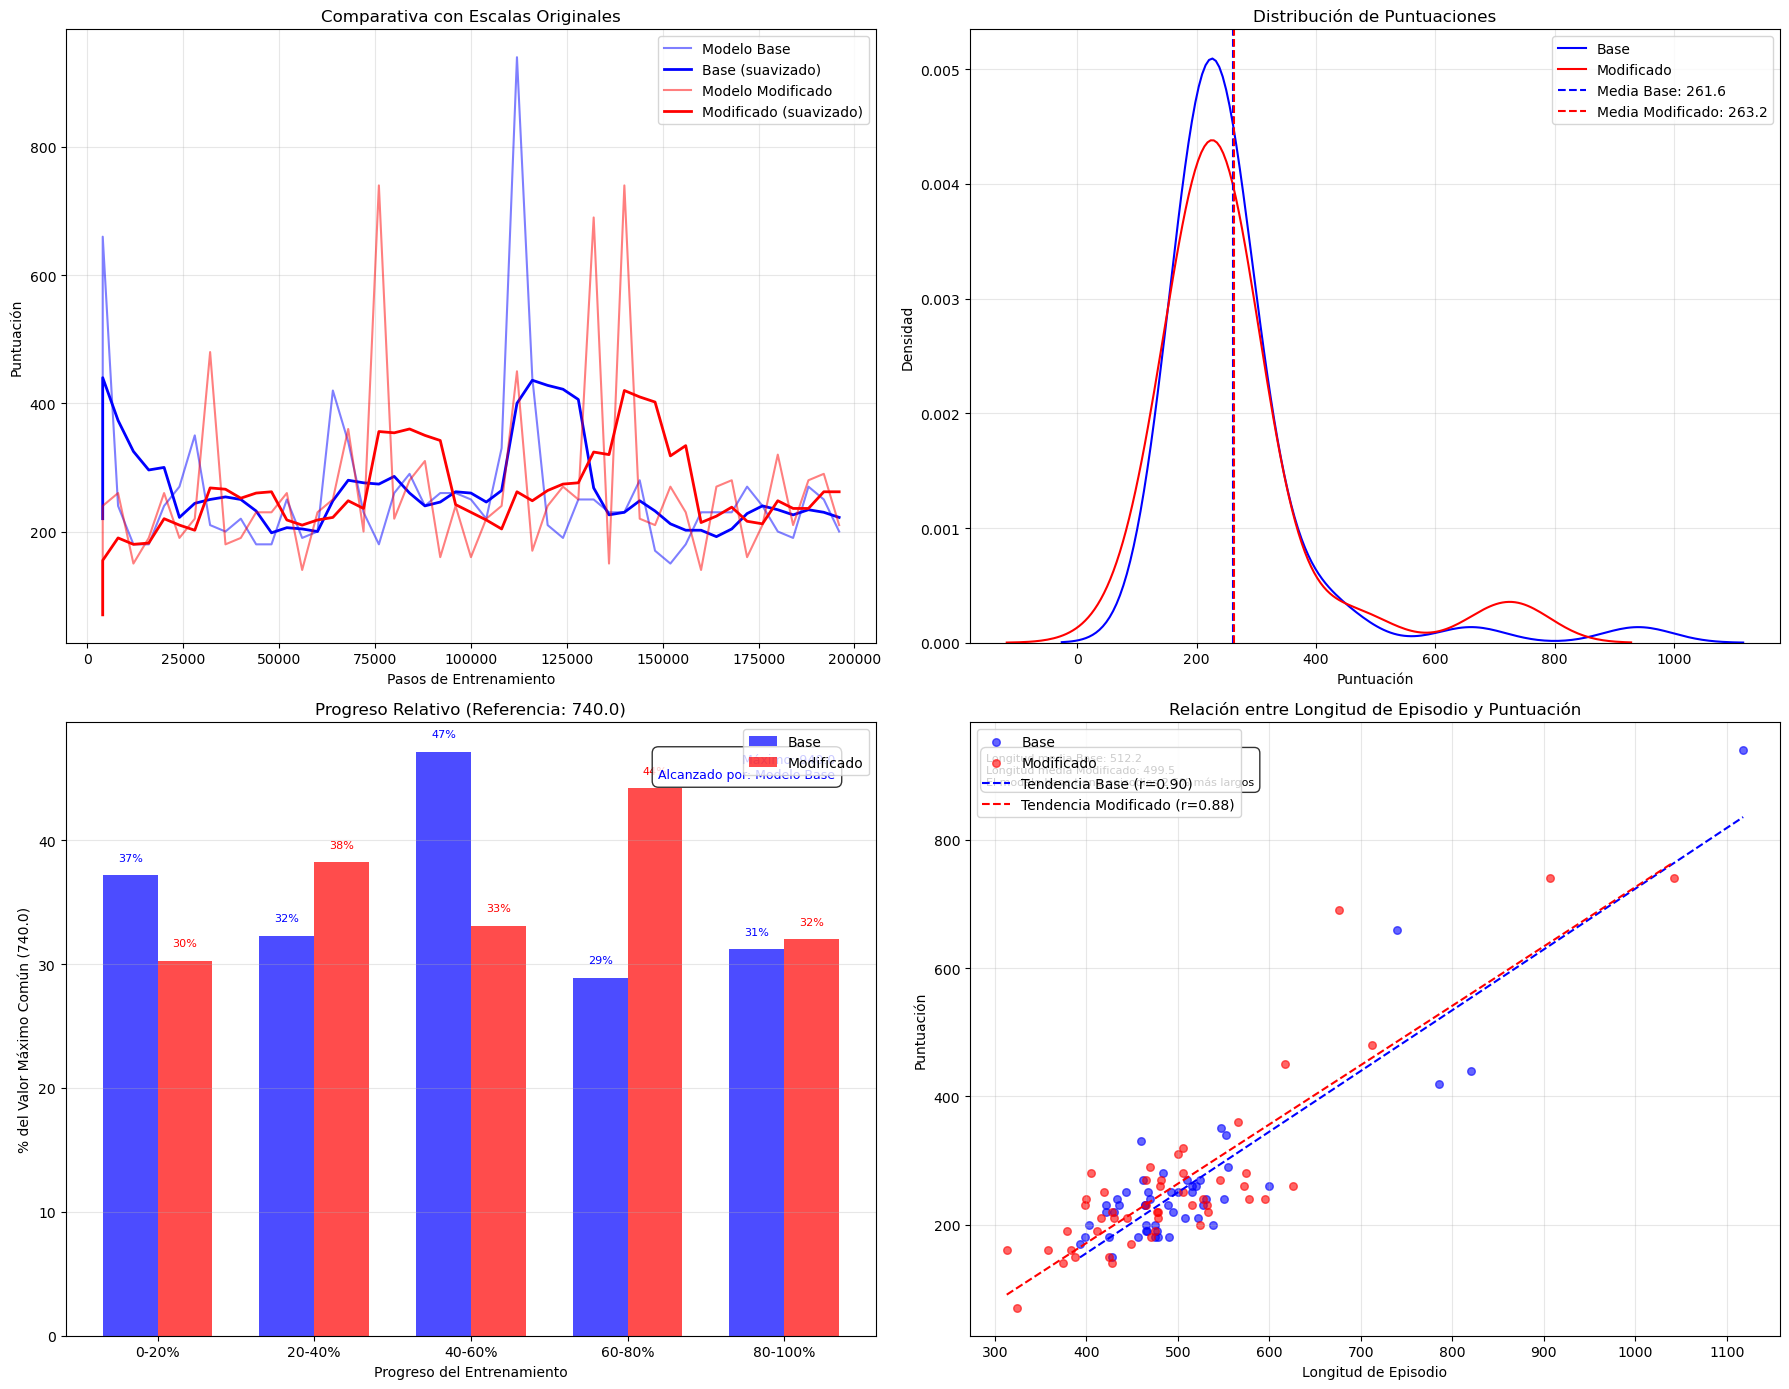

,Métrica,Modelo Base,Modelo Modificado
0,Rango de Pasos,"4,000 - 196,000","4,000 - 196,000"
1,Puntuación Media,261.60,263.20
2,Puntuación Máxima,940.00,740.00
3,Desviación Estándar,128.28,137.16
4,Coeficiente de Variación (%),49.03%,52.11%
5,Mediana,230.00,230.00
6,Progreso Inicial (primeros 25%),256.15,222.31
7,Progreso Final (últimos 25%),216.15,236.92
8,Mejora Relativa (%),-15.62%,6.57%



Conclusiones del análisis:
✓ El modelo modificado logra una puntuación media 0.6% superior al modelo base
✗ El modelo base muestra mayor estabilidad en sus resultados (CV: 49.0% vs 52.1%)
✓ El modelo modificado es 0.6% más eficiente en términos de puntos por paso
  • Eficiencia base: 0.00133469 puntos/paso (749 pasos para obtener 1 punto)
  • Eficiencia modificada: 0.00134286 puntos/paso (745 pasos para obtener 1 punto)
  • El modelo modificado requiere 0.6% menos pasos para lograr la misma puntuación
✓ El modelo modificado muestra una mejora más pronunciada durante el entrenamiento (6.6% vs -15.6%)


In [6]:
# Visualización comparativa ajustada para rangos de pasos no superpuestos
print("\nComparativa ajustada entre modelo base y modelo modificado:\n" + "-"*50)

# Filtrar solo datos de entrenamiento
base_train_df = base_df[base_df['eval_return'].notna()].copy().sort_values('step')
modified_train_df = modified_df[modified_df['eval_return'].notna()].copy().sort_values('step')

# Renombrar columnas para uniformidad
base_train_df = base_train_df.rename(columns={'eval_return': 'score'})
modified_train_df = modified_train_df.rename(columns={'eval_return': 'score'})

# Añadir identificadores de modelo
base_train_df['model'] = 'base'
modified_train_df['model'] = 'modified'

# Verificar disponibilidad de datos
if len(base_train_df) > 0 and len(modified_train_df) > 0:
    print(f"Modelo base: {len(base_train_df)} registros, pasos {base_train_df['step'].min():,.0f} a {base_train_df['step'].max():,.0f}")
    print(f"Modelo modificado: {len(modified_train_df)} registros, pasos {modified_train_df['step'].min():,.0f} a {modified_train_df['step'].max():,.0f}")
    
    # Crear visualizaciones comparativas
    plt.figure(figsize=(18, 14))
    
    # 1. Comparativa con escalas originales (primer gráfico)
    plt.subplot(2, 2, 1)
    plt.plot(base_train_df['step'], base_train_df['score'], 'b-', alpha=0.5, label='Modelo Base')
    
    # Añadir suavizado para el modelo base
    window_size_base = min(5, len(base_train_df))
    if window_size_base > 1:
        base_train_df['smooth_score'] = base_train_df['score'].rolling(window=window_size_base, min_periods=1).mean()
        plt.plot(base_train_df['step'], base_train_df['smooth_score'], 'b-', linewidth=2, label='Base (suavizado)')
    
    plt.plot(modified_train_df['step'], modified_train_df['score'], 'r-', alpha=0.5, label='Modelo Modificado')
    
    # Añadir suavizado para el modelo modificado
    window_size_mod = min(5, len(modified_train_df))
    if window_size_mod > 1:
        modified_train_df['smooth_score'] = modified_train_df['score'].rolling(window=window_size_mod, min_periods=1).mean()
        plt.plot(modified_train_df['step'], modified_train_df['smooth_score'], 'r-', linewidth=2, label='Modificado (suavizado)')
    
    plt.title('Comparativa con Escalas Originales')
    plt.xlabel('Pasos de Entrenamiento')
    plt.ylabel('Puntuación')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # 2. Distribución de puntuaciones
    plt.subplot(2, 2, 2)
    
    try:
        sns.kdeplot(base_train_df['score'], color='blue', label='Base')
        sns.kdeplot(modified_train_df['score'], color='red', label='Modificado')
        
        plt.axvline(base_train_df['score'].mean(), color='blue', linestyle='--', 
                   label=f'Media Base: {base_train_df["score"].mean():.1f}')
        plt.axvline(modified_train_df['score'].mean(), color='red', linestyle='--',
                   label=f'Media Modificado: {modified_train_df["score"].mean():.1f}')
    except:
        # Si hay error en KDE (por ejemplo, con muy pocos puntos), usar histograma simple
        plt.hist(base_train_df['score'], alpha=0.5, color='blue', label='Base')
        plt.hist(modified_train_df['score'], alpha=0.5, color='red', label='Modificado')
        
        plt.axvline(base_train_df['score'].mean(), color='blue', linestyle='--', 
                   label=f'Media Base: {base_train_df["score"].mean():.1f}')
        plt.axvline(modified_train_df['score'].mean(), color='red', linestyle='--',
                   label=f'Media Modificado: {modified_train_df["score"].mean():.1f}')
    
    plt.title('Distribución de Puntuaciones')
    plt.xlabel('Puntuación')
    plt.ylabel('Densidad')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # 3. Métricas de progreso relativo (mejorado)
    plt.subplot(2, 2, 3)
    
    try:
        # Añadir normalización de pasos para poder segmentar el progreso
        base_train_df['normalized_step'] = base_train_df['step'] / base_train_df['step'].max()
        modified_train_df['normalized_step'] = modified_train_df['step'] / modified_train_df['step'].max()
        
        # Calcular métricas relativas usando el mínimo máximo entre ambos modelos para una comparación justa
        base_max = base_train_df['score'].max()
        modified_max = modified_train_df['score'].max()
        min_max_score = min(base_max, modified_max)
        max_score = max(base_max, modified_max)
        
        # Determinar qué modelo alcanza el máximo
        if base_max >= modified_max:
            max_model = "Modelo Base"
            max_color = "blue"
        else:
            max_model = "Modelo Modificado"
            max_color = "red"
        
        # Dividir los datos en segmentos de progreso
        n_segments = 5  # Usar 5 segmentos para simplificar
        
        # Función para dividir los datos en segmentos
        def create_segments(df, n_segments, reference_max):
            result = []
            for i in range(n_segments):
                min_pct = i / n_segments
                max_pct = (i + 1) / n_segments
                segment_data = df[(df['normalized_step'] >= min_pct) & 
                                 (df['normalized_step'] < max_pct if i < n_segments-1 else df['normalized_step'] <= max_pct)]
                
                if len(segment_data) > 0:
                    avg_score = segment_data['score'].mean()
                    max_score = segment_data['score'].max()
                else:
                    avg_score = np.nan
                    max_score = np.nan
                    
                result.append({
                    'segment': i,
                    'label': f'{int(min_pct*100)}-{int(max_pct*100)}%',
                    'avg_score': avg_score,
                    'max_score': max_score,
                    'pct_of_common_max': (avg_score / reference_max * 100) if not np.isnan(avg_score) else np.nan
                })
            return result
        
        # Usar el mínimo máximo para una comparación justa
        base_segments = create_segments(base_train_df, n_segments, min_max_score)
        mod_segments = create_segments(modified_train_df, n_segments, min_max_score)
        
        # Preparar datos para el gráfico de barras
        x_pos = np.arange(n_segments)
        width = 0.35
        
        base_heights = [s['pct_of_common_max'] for s in base_segments]
        mod_heights = [s['pct_of_common_max'] for s in mod_segments]
        
        # Reemplazar NaN por 0 para el gráfico
        base_heights = np.nan_to_num(base_heights)
        mod_heights = np.nan_to_num(mod_heights)
        
        # Crear gráfico de barras
        bars_base = plt.bar(x_pos - width/2, base_heights, width, label='Base', color='blue', alpha=0.7)
        bars_mod = plt.bar(x_pos + width/2, mod_heights, width, label='Modificado', color='red', alpha=0.7)
        
        # Añadir los valores numéricos sobre cada barra
        def add_labels(bars, heights, is_base=True):
            for bar, height in zip(bars, heights):
                if height > 0:
                    color = 'blue' if is_base else 'red'
                    plt.text(
                        bar.get_x() + bar.get_width() / 2,
                        height + 1,  # Ajustar posición vertical
                        f"{height:.0f}%",
                        ha='center',
                        va='bottom',
                        color=color,
                        fontsize=8,
                        rotation=0
                    )
        
        add_labels(bars_base, base_heights, True)
        add_labels(bars_mod, mod_heights, False)
        
        # Configurar etiquetas
        labels = [s['label'] for s in base_segments]
        plt.xticks(x_pos, labels)
        plt.xlabel('Progreso del Entrenamiento')
        plt.ylabel(f'% del Valor Máximo Común ({min_max_score:.1f})')
        
        # Indicar quién tiene el máximo y su valor
        plt.title(f'Progreso Relativo (Referencia: {min_max_score:.1f})')
        plt.annotate(f"Máximo: {max_score:.1f}\nAlcanzado por: {max_model}", 
                   xy=(0.95, 0.95), xycoords='axes fraction',
                   horizontalalignment='right', verticalalignment='top',
                   color=max_color, fontsize=9,
                   bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
        
        plt.grid(True, alpha=0.3, axis='y')
        plt.legend()
    
    except Exception as e:
        # En caso de error, mostrar mensaje simplificado
        plt.text(0.5, 0.5, "No se pudo crear el gráfico de progreso relativo", 
                 ha='center', va='center', transform=plt.gca().transAxes)
        print(f"Error en el gráfico: {str(e)}")
        plt.axis('off')
    
    # 4. NUEVA GRÁFICA: Relación entre longitud de episodio y puntuación
    plt.subplot(2, 2, 4)
    
    try:
        # Scatter plot para ver la relación entre longitud y puntuación
        plt.scatter(base_train_df['eval_length'], base_train_df['score'], 
                   color='blue', alpha=0.6, s=30, label='Base')
        plt.scatter(modified_train_df['eval_length'], modified_train_df['score'], 
                   color='red', alpha=0.6, s=30, label='Modificado')
        
        # Añadir líneas de tendencia
        if len(base_train_df) > 1:
            z_base = np.polyfit(base_train_df['eval_length'], base_train_df['score'], 1)
            p_base = np.poly1d(z_base)
            x_range_base = np.linspace(base_train_df['eval_length'].min(), base_train_df['eval_length'].max(), 100)
            plt.plot(x_range_base, p_base(x_range_base), 'b--', 
                    label=f'Tendencia Base (r={np.corrcoef(base_train_df["eval_length"], base_train_df["score"])[0,1]:.2f})')
        
        if len(modified_train_df) > 1:
            z_mod = np.polyfit(modified_train_df['eval_length'], modified_train_df['score'], 1)
            p_mod = np.poly1d(z_mod)
            x_range_mod = np.linspace(modified_train_df['eval_length'].min(), modified_train_df['eval_length'].max(), 100)
            plt.plot(x_range_mod, p_mod(x_range_mod), 'r--', 
                    label=f'Tendencia Modificado (r={np.corrcoef(modified_train_df["eval_length"], modified_train_df["score"])[0,1]:.2f})')
        
        plt.title('Relación entre Longitud de Episodio y Puntuación')
        plt.xlabel('Longitud de Episodio')
        plt.ylabel('Puntuación')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        # Añadir anotaciones estadísticas adicionales
        mean_length_base = base_train_df['eval_length'].mean()
        mean_length_mod = modified_train_df['eval_length'].mean()
        
        stats_text = f"Longitud media Base: {mean_length_base:.1f}\n" \
                     f"Longitud media Modificado: {mean_length_mod:.1f}\n"
        
        # Determinar cuál modelo tiene episodios más largos
        if mean_length_mod > mean_length_base:
            diff_pct = (mean_length_mod / mean_length_base - 1) * 100
            stats_text += f"El modelo modificado tiene episodios {diff_pct:.1f}% más largos"
        else:
            diff_pct = (mean_length_base / mean_length_mod - 1) * 100
            stats_text += f"El modelo base tiene episodios {diff_pct:.1f}% más largos"
        
        plt.annotate(stats_text, xy=(0.02, 0.95), xycoords='axes fraction',
                   horizontalalignment='left', verticalalignment='top',
                   fontsize=8, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
    
    except Exception as e:
        # En caso de error, mostrar mensaje simplificado
        plt.text(0.5, 0.5, "No se pudo crear el gráfico de relación entre longitud y puntuación", 
                 ha='center', va='center', transform=plt.gca().transAxes)
        print(f"Error en el gráfico: {str(e)}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
    
# Tabla comparativa de métricas clave
    try:
        metrics_table = {
            'Métrica': [
                'Rango de Pasos', 
                'Puntuación Media', 
                'Puntuación Máxima',
                'Desviación Estándar',
                'Coeficiente de Variación (%)',
                'Mediana'
            ],
            'Modelo Base': [
                f"{base_train_df['step'].min():,.0f} - {base_train_df['step'].max():,.0f}",
                f"{base_train_df['score'].mean():.2f}",
                f"{base_train_df['score'].max():.2f}",
                f"{base_train_df['score'].std():.2f}",
                f"{(base_train_df['score'].std() / base_train_df['score'].mean() * 100):.2f}%",
                f"{base_train_df['score'].median():.2f}"
            ],
            'Modelo Modificado': [
                f"{modified_train_df['step'].min():,.0f} - {modified_train_df['step'].max():,.0f}",
                f"{modified_train_df['score'].mean():.2f}",
                f"{modified_train_df['score'].max():.2f}",
                f"{modified_train_df['score'].std():.2f}",
                f"{(modified_train_df['score'].std() / modified_train_df['score'].mean() * 100):.2f}%",
                f"{modified_train_df['score'].median():.2f}"
            ]
        }
        
        # Solo añadir métricas de progreso si hay suficientes datos
        if len(base_train_df) > 3 and len(modified_train_df) > 3:
            # Calcular cuartiles
            base_25p = base_train_df[base_train_df['normalized_step'] <= 0.25]
            base_75p = base_train_df[base_train_df['normalized_step'] >= 0.75]
            mod_25p = modified_train_df[modified_train_df['normalized_step'] <= 0.25]
            mod_75p = modified_train_df[modified_train_df['normalized_step'] >= 0.75]
            
            if len(base_25p) > 0 and len(base_75p) > 0 and len(mod_25p) > 0 and len(mod_75p) > 0:
                # Añadir métricas adicionales solo si hay datos en los cuartiles
                metrics_table['Métrica'].extend([
                    'Progreso Inicial (primeros 25%)',
                    'Progreso Final (últimos 25%)',
                    'Mejora Relativa (%)'
                ])
                
                # Calcular valores para el modelo base
                base_init = base_25p['score'].mean()
                base_final = base_75p['score'].mean()
                base_improvement = ((base_final / base_init) - 1) * 100 if base_init > 0 else 0
                
                metrics_table['Modelo Base'].extend([
                    f"{base_init:.2f}",
                    f"{base_final:.2f}",
                    f"{base_improvement:.2f}%"
                ])
                
                # Calcular valores para el modelo modificado
                mod_init = mod_25p['score'].mean()
                mod_final = mod_75p['score'].mean()
                mod_improvement = ((mod_final / mod_init) - 1) * 100 if mod_init > 0 else 0
                
                metrics_table['Modelo Modificado'].extend([
                    f"{mod_init:.2f}",
                    f"{mod_final:.2f}",
                    f"{mod_improvement:.2f}%"
                ])
        
        metrics_df = pd.DataFrame(metrics_table)
        display(HTML("<h3>Comparativa de Métricas entre Modelos</h3>"))
        display(metrics_df)
        
        # Conclusiones automáticas
        # Conclusiones automáticas
        print("\nConclusiones del análisis:")

        # Comparar puntuación media
        base_mean = base_train_df['score'].mean()
        mod_mean = modified_train_df['score'].mean()

        if mod_mean > base_mean:
            print(f"✓ El modelo modificado logra una puntuación media {(mod_mean/base_mean - 1)*100:.1f}% superior al modelo base")
        else:
            print(f"✗ El modelo modificado logra una puntuación media {(1 - mod_mean/base_mean)*100:.1f}% inferior al modelo base")

        # Comparar estabilidad (menor coeficiente de variación es mejor)
        base_cv = base_train_df['score'].std() / base_train_df['score'].mean() * 100
        mod_cv = modified_train_df['score'].std() / modified_train_df['score'].mean() * 100

        if mod_cv < base_cv:
            print(f"✓ El modelo modificado muestra mayor estabilidad en sus resultados (CV: {mod_cv:.1f}% vs {base_cv:.1f}%)")
        else:
            print(f"✗ El modelo base muestra mayor estabilidad en sus resultados (CV: {base_cv:.1f}% vs {mod_cv:.1f}%)")
            
        # Eficiencia de entrenamiento (puntos por paso) - VERSIÓN MEJORADA
        base_efficiency = base_train_df['score'].mean() / base_train_df['step'].max()
        mod_efficiency = modified_train_df['score'].mean() / modified_train_df['step'].max()
        efficiency_diff_pct = abs(mod_efficiency/base_efficiency - 1) * 100

        # Calcular cuántos pasos necesita cada modelo para obtener un punto de puntuación
        base_steps_per_point = 1 / base_efficiency
        mod_steps_per_point = 1 / mod_efficiency

        if mod_efficiency > base_efficiency:
            print(f"✓ El modelo modificado es {efficiency_diff_pct:.1f}% más eficiente en términos de puntos por paso")
            print(f"  • Eficiencia base: {base_efficiency:.8f} puntos/paso ({base_steps_per_point:.0f} pasos para obtener 1 punto)")
            print(f"  • Eficiencia modificada: {mod_efficiency:.8f} puntos/paso ({mod_steps_per_point:.0f} pasos para obtener 1 punto)")
            print(f"  • El modelo modificado requiere {(base_steps_per_point/mod_steps_per_point - 1)*100:.1f}% menos pasos para lograr la misma puntuación")
        else:
            print(f"✗ El modelo base es {efficiency_diff_pct:.1f}% más eficiente en términos de puntos por paso")
            print(f"  • Eficiencia base: {base_efficiency:.8f} puntos/paso ({base_steps_per_point:.0f} pasos para obtener 1 punto)")
            print(f"  • Eficiencia modificada: {mod_efficiency:.8f} puntos/paso ({mod_steps_per_point:.0f} pasos para obtener 1 punto)")
            print(f"  • El modelo base requiere {(mod_steps_per_point/base_steps_per_point - 1)*100:.1f}% menos pasos para lograr la misma puntuación")
            
        # Solo mostrar la comparación de mejora si tenemos datos suficientes
        if 'base_improvement' in locals() and 'mod_improvement' in locals():
            if mod_improvement > base_improvement:
                print(f"✓ El modelo modificado muestra una mejora más pronunciada durante el entrenamiento ({mod_improvement:.1f}% vs {base_improvement:.1f}%)")
            else:
                print(f"✗ El modelo base muestra una mejora más pronunciada durante el entrenamiento ({base_improvement:.1f}% vs {mod_improvement:.1f}%)")
    except Exception as e:
        print(f"Error al crear tabla comparativa o conclusiones: {str(e)}")
else:
    print("No hay suficientes datos para realizar la comparación")

In [7]:
# Convertir a DataFrame para facilitar el análisis
# Cargar datos
base_df = load_jsonl(file_path='metrics_baseV3.jsonl')  # Usa el archivo .jsonl por defecto
modified_df = load_jsonl(file_path='metrics_modV3.jsonl')  # Usa el archivo .jsonl por defecto

# Convertir a DataFrame
base_df = pd.DataFrame(base_df)
modified_df = pd.DataFrame(modified_df)

print(f"Base DataFrame shape: {base_df.shape}")
print(f"Modified DataFrame shape: {modified_df.shape}")

Base DataFrame shape: (604, 13)
Modified DataFrame shape: (610, 13)



Comparativa ajustada entre modelo base y modelo modificado:
--------------------------------------------------
Modelo base: 200 registros, pasos 4,000 a 796,000
Modelo modificado: 200 registros, pasos 4,000 a 796,000


c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


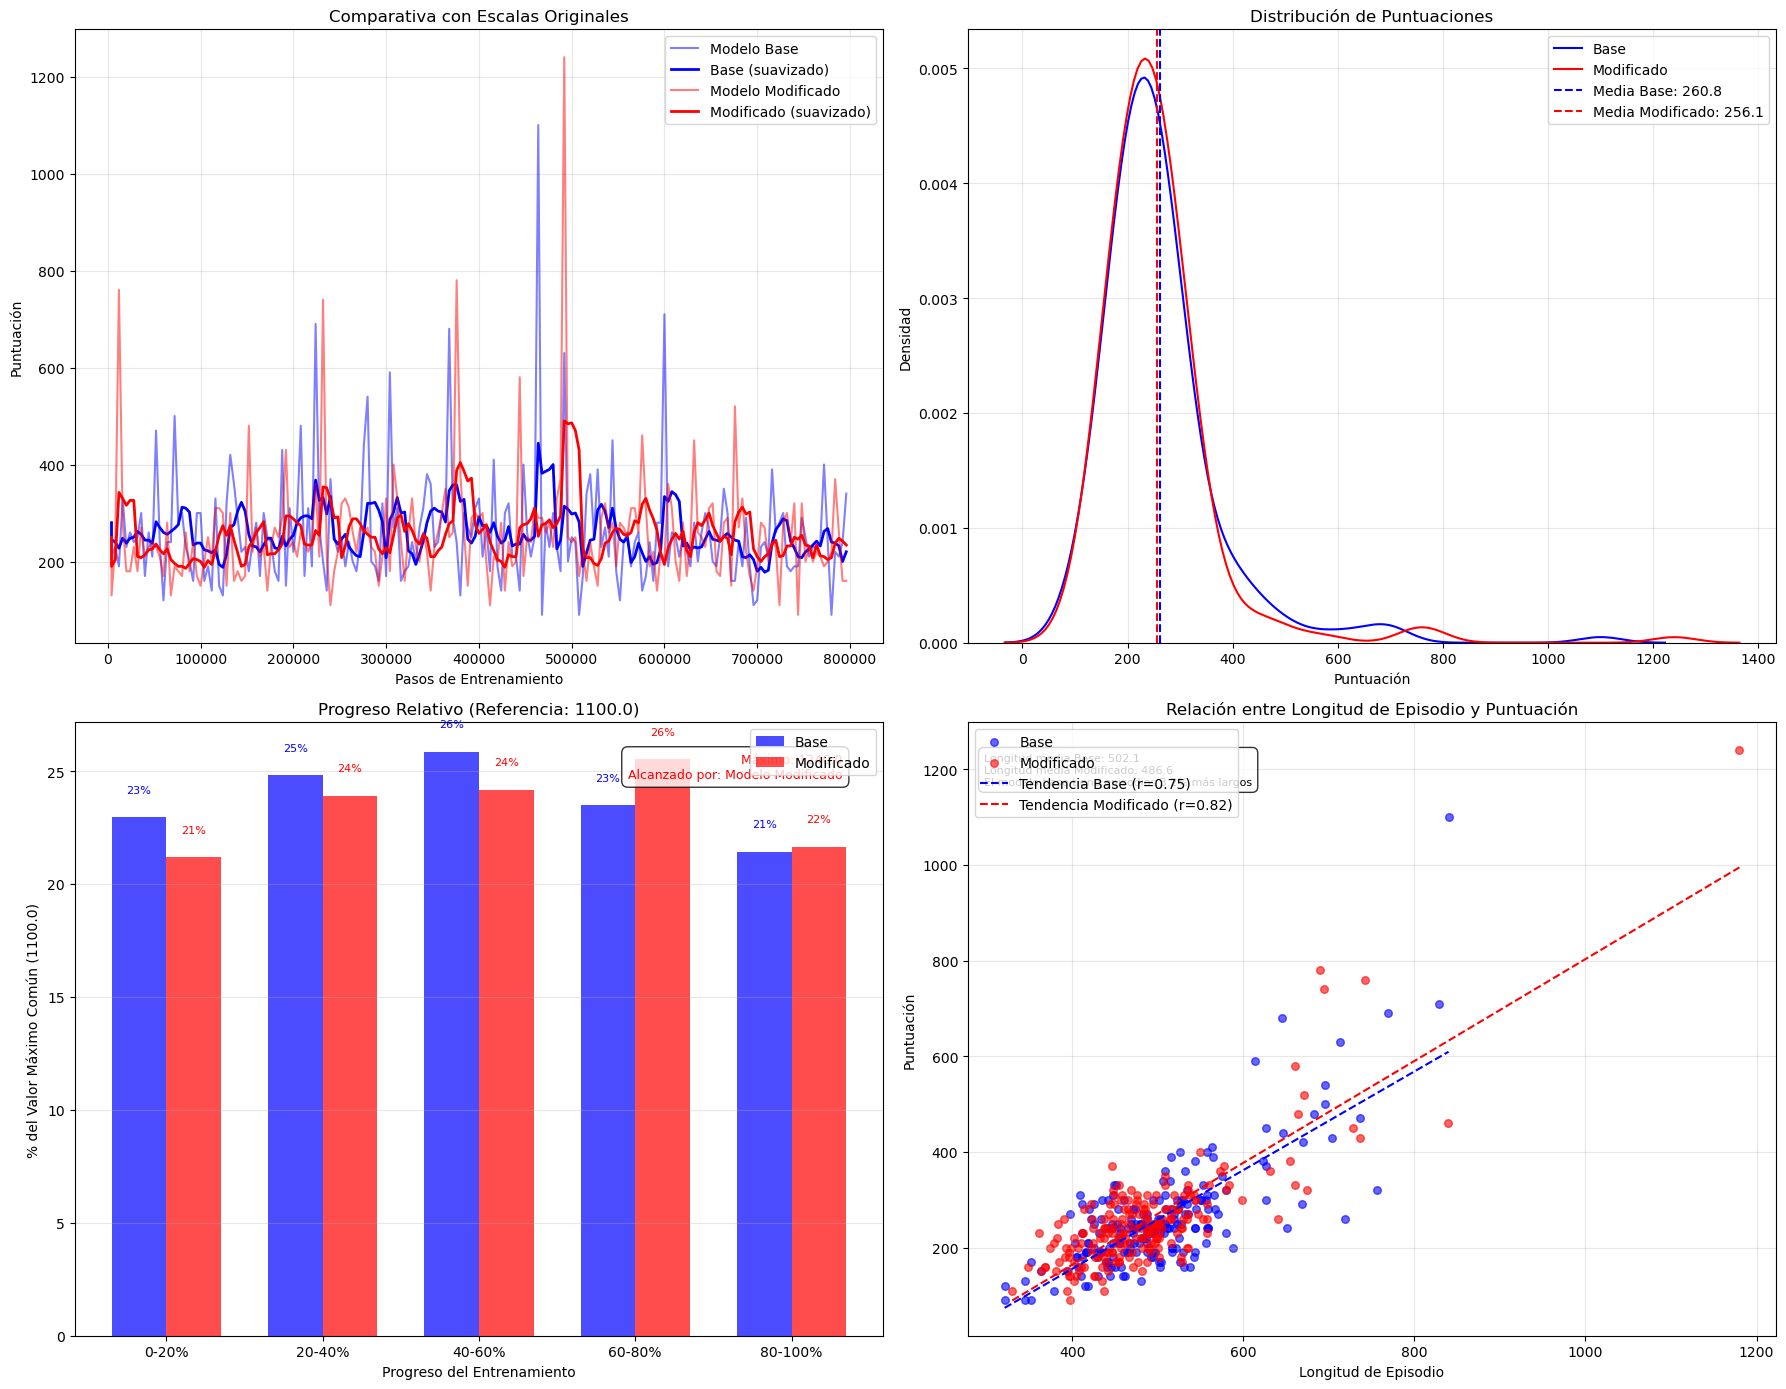

,Métrica,Modelo Base,Modelo Modificado
0,Rango de Pasos,"4,000 - 796,000","4,000 - 796,000"
1,Puntuación Media,260.80,256.15
2,Puntuación Máxima,1100.00,1240.00
3,Desviación Estándar,117.54,119.08
4,Coeficiente de Variación (%),45.07%,46.49%
5,Mediana,240.00,240.00
6,Progreso Inicial (primeros 25%),251.40,237.40
7,Progreso Final (últimos 25%),243.80,243.00
8,Mejora Relativa (%),-3.02%,2.36%



Conclusiones del análisis:
✗ El modelo modificado logra una puntuación media 1.8% inferior al modelo base
✗ El modelo base muestra mayor estabilidad en sus resultados (CV: 45.1% vs 46.5%)
✗ El modelo base es 1.8% más eficiente en términos de puntos por paso
  • Eficiencia base: 0.00032764 puntos/paso (3052 pasos para obtener 1 punto)
  • Eficiencia modificada: 0.00032180 puntos/paso (3108 pasos para obtener 1 punto)
  • El modelo base requiere 1.8% menos pasos para lograr la misma puntuación
✓ El modelo modificado muestra una mejora más pronunciada durante el entrenamiento (2.4% vs -3.0%)


In [8]:
# Visualización comparativa ajustada para rangos de pasos no superpuestos
print("\nComparativa ajustada entre modelo base y modelo modificado:\n" + "-"*50)

# Filtrar solo datos de entrenamiento
base_train_df = base_df[base_df['eval_return'].notna()].copy().sort_values('step')
modified_train_df = modified_df[modified_df['eval_return'].notna()].copy().sort_values('step')

# Renombrar columnas para uniformidad
base_train_df = base_train_df.rename(columns={'eval_return': 'score'})
modified_train_df = modified_train_df.rename(columns={'eval_return': 'score'})

# Añadir identificadores de modelo
base_train_df['model'] = 'base'
modified_train_df['model'] = 'modified'

# Verificar disponibilidad de datos
if len(base_train_df) > 0 and len(modified_train_df) > 0:
    print(f"Modelo base: {len(base_train_df)} registros, pasos {base_train_df['step'].min():,.0f} a {base_train_df['step'].max():,.0f}")
    print(f"Modelo modificado: {len(modified_train_df)} registros, pasos {modified_train_df['step'].min():,.0f} a {modified_train_df['step'].max():,.0f}")
    
    # Crear visualizaciones comparativas
    plt.figure(figsize=(18, 14))
    
    # 1. Comparativa con escalas originales (primer gráfico)
    plt.subplot(2, 2, 1)
    plt.plot(base_train_df['step'], base_train_df['score'], 'b-', alpha=0.5, label='Modelo Base')
    
    # Añadir suavizado para el modelo base
    window_size_base = min(5, len(base_train_df))
    if window_size_base > 1:
        base_train_df['smooth_score'] = base_train_df['score'].rolling(window=window_size_base, min_periods=1).mean()
        plt.plot(base_train_df['step'], base_train_df['smooth_score'], 'b-', linewidth=2, label='Base (suavizado)')
    
    plt.plot(modified_train_df['step'], modified_train_df['score'], 'r-', alpha=0.5, label='Modelo Modificado')
    
    # Añadir suavizado para el modelo modificado
    window_size_mod = min(5, len(modified_train_df))
    if window_size_mod > 1:
        modified_train_df['smooth_score'] = modified_train_df['score'].rolling(window=window_size_mod, min_periods=1).mean()
        plt.plot(modified_train_df['step'], modified_train_df['smooth_score'], 'r-', linewidth=2, label='Modificado (suavizado)')
    
    plt.title('Comparativa con Escalas Originales')
    plt.xlabel('Pasos de Entrenamiento')
    plt.ylabel('Puntuación')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # 2. Distribución de puntuaciones
    plt.subplot(2, 2, 2)
    
    try:
        sns.kdeplot(base_train_df['score'], color='blue', label='Base')
        sns.kdeplot(modified_train_df['score'], color='red', label='Modificado')
        
        plt.axvline(base_train_df['score'].mean(), color='blue', linestyle='--', 
                   label=f'Media Base: {base_train_df["score"].mean():.1f}')
        plt.axvline(modified_train_df['score'].mean(), color='red', linestyle='--',
                   label=f'Media Modificado: {modified_train_df["score"].mean():.1f}')
    except:
        # Si hay error en KDE (por ejemplo, con muy pocos puntos), usar histograma simple
        plt.hist(base_train_df['score'], alpha=0.5, color='blue', label='Base')
        plt.hist(modified_train_df['score'], alpha=0.5, color='red', label='Modificado')
        
        plt.axvline(base_train_df['score'].mean(), color='blue', linestyle='--', 
                   label=f'Media Base: {base_train_df["score"].mean():.1f}')
        plt.axvline(modified_train_df['score'].mean(), color='red', linestyle='--',
                   label=f'Media Modificado: {modified_train_df["score"].mean():.1f}')
    
    plt.title('Distribución de Puntuaciones')
    plt.xlabel('Puntuación')
    plt.ylabel('Densidad')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # 3. Métricas de progreso relativo (mejorado)
    plt.subplot(2, 2, 3)
    
    try:
        # Añadir normalización de pasos para poder segmentar el progreso
        base_train_df['normalized_step'] = base_train_df['step'] / base_train_df['step'].max()
        modified_train_df['normalized_step'] = modified_train_df['step'] / modified_train_df['step'].max()
        
        # Calcular métricas relativas usando el mínimo máximo entre ambos modelos para una comparación justa
        base_max = base_train_df['score'].max()
        modified_max = modified_train_df['score'].max()
        min_max_score = min(base_max, modified_max)
        max_score = max(base_max, modified_max)
        
        # Determinar qué modelo alcanza el máximo
        if base_max >= modified_max:
            max_model = "Modelo Base"
            max_color = "blue"
        else:
            max_model = "Modelo Modificado"
            max_color = "red"
        
        # Dividir los datos en segmentos de progreso
        n_segments = 5  # Usar 5 segmentos para simplificar
        
        # Función para dividir los datos en segmentos
        def create_segments(df, n_segments, reference_max):
            result = []
            for i in range(n_segments):
                min_pct = i / n_segments
                max_pct = (i + 1) / n_segments
                segment_data = df[(df['normalized_step'] >= min_pct) & 
                                 (df['normalized_step'] < max_pct if i < n_segments-1 else df['normalized_step'] <= max_pct)]
                
                if len(segment_data) > 0:
                    avg_score = segment_data['score'].mean()
                    max_score = segment_data['score'].max()
                else:
                    avg_score = np.nan
                    max_score = np.nan
                    
                result.append({
                    'segment': i,
                    'label': f'{int(min_pct*100)}-{int(max_pct*100)}%',
                    'avg_score': avg_score,
                    'max_score': max_score,
                    'pct_of_common_max': (avg_score / reference_max * 100) if not np.isnan(avg_score) else np.nan
                })
            return result
        
        # Usar el mínimo máximo para una comparación justa
        base_segments = create_segments(base_train_df, n_segments, min_max_score)
        mod_segments = create_segments(modified_train_df, n_segments, min_max_score)
        
        # Preparar datos para el gráfico de barras
        x_pos = np.arange(n_segments)
        width = 0.35
        
        base_heights = [s['pct_of_common_max'] for s in base_segments]
        mod_heights = [s['pct_of_common_max'] for s in mod_segments]
        
        # Reemplazar NaN por 0 para el gráfico
        base_heights = np.nan_to_num(base_heights)
        mod_heights = np.nan_to_num(mod_heights)
        
        # Crear gráfico de barras
        bars_base = plt.bar(x_pos - width/2, base_heights, width, label='Base', color='blue', alpha=0.7)
        bars_mod = plt.bar(x_pos + width/2, mod_heights, width, label='Modificado', color='red', alpha=0.7)
        
        # Añadir los valores numéricos sobre cada barra
        def add_labels(bars, heights, is_base=True):
            for bar, height in zip(bars, heights):
                if height > 0:
                    color = 'blue' if is_base else 'red'
                    plt.text(
                        bar.get_x() + bar.get_width() / 2,
                        height + 1,  # Ajustar posición vertical
                        f"{height:.0f}%",
                        ha='center',
                        va='bottom',
                        color=color,
                        fontsize=8,
                        rotation=0
                    )
        
        add_labels(bars_base, base_heights, True)
        add_labels(bars_mod, mod_heights, False)
        
        # Configurar etiquetas
        labels = [s['label'] for s in base_segments]
        plt.xticks(x_pos, labels)
        plt.xlabel('Progreso del Entrenamiento')
        plt.ylabel(f'% del Valor Máximo Común ({min_max_score:.1f})')
        
        # Indicar quién tiene el máximo y su valor
        plt.title(f'Progreso Relativo (Referencia: {min_max_score:.1f})')
        plt.annotate(f"Máximo: {max_score:.1f}\nAlcanzado por: {max_model}", 
                   xy=(0.95, 0.95), xycoords='axes fraction',
                   horizontalalignment='right', verticalalignment='top',
                   color=max_color, fontsize=9,
                   bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
        
        plt.grid(True, alpha=0.3, axis='y')
        plt.legend()
    
    except Exception as e:
        # En caso de error, mostrar mensaje simplificado
        plt.text(0.5, 0.5, "No se pudo crear el gráfico de progreso relativo", 
                 ha='center', va='center', transform=plt.gca().transAxes)
        print(f"Error en el gráfico: {str(e)}")
        plt.axis('off')
    
    # 4. NUEVA GRÁFICA: Relación entre longitud de episodio y puntuación
    plt.subplot(2, 2, 4)
    
    try:
        # Scatter plot para ver la relación entre longitud y puntuación
        plt.scatter(base_train_df['eval_length'], base_train_df['score'], 
                   color='blue', alpha=0.6, s=30, label='Base')
        plt.scatter(modified_train_df['eval_length'], modified_train_df['score'], 
                   color='red', alpha=0.6, s=30, label='Modificado')
        
        # Añadir líneas de tendencia
        if len(base_train_df) > 1:
            z_base = np.polyfit(base_train_df['eval_length'], base_train_df['score'], 1)
            p_base = np.poly1d(z_base)
            x_range_base = np.linspace(base_train_df['eval_length'].min(), base_train_df['eval_length'].max(), 100)
            plt.plot(x_range_base, p_base(x_range_base), 'b--', 
                    label=f'Tendencia Base (r={np.corrcoef(base_train_df["eval_length"], base_train_df["score"])[0,1]:.2f})')
        
        if len(modified_train_df) > 1:
            z_mod = np.polyfit(modified_train_df['eval_length'], modified_train_df['score'], 1)
            p_mod = np.poly1d(z_mod)
            x_range_mod = np.linspace(modified_train_df['eval_length'].min(), modified_train_df['eval_length'].max(), 100)
            plt.plot(x_range_mod, p_mod(x_range_mod), 'r--', 
                    label=f'Tendencia Modificado (r={np.corrcoef(modified_train_df["eval_length"], modified_train_df["score"])[0,1]:.2f})')
        
        plt.title('Relación entre Longitud de Episodio y Puntuación')
        plt.xlabel('Longitud de Episodio')
        plt.ylabel('Puntuación')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        # Añadir anotaciones estadísticas adicionales
        mean_length_base = base_train_df['eval_length'].mean()
        mean_length_mod = modified_train_df['eval_length'].mean()
        
        stats_text = f"Longitud media Base: {mean_length_base:.1f}\n" \
                     f"Longitud media Modificado: {mean_length_mod:.1f}\n"
        
        # Determinar cuál modelo tiene episodios más largos
        if mean_length_mod > mean_length_base:
            diff_pct = (mean_length_mod / mean_length_base - 1) * 100
            stats_text += f"El modelo modificado tiene episodios {diff_pct:.1f}% más largos"
        else:
            diff_pct = (mean_length_base / mean_length_mod - 1) * 100
            stats_text += f"El modelo base tiene episodios {diff_pct:.1f}% más largos"
        
        plt.annotate(stats_text, xy=(0.02, 0.95), xycoords='axes fraction',
                   horizontalalignment='left', verticalalignment='top',
                   fontsize=8, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
    
    except Exception as e:
        # En caso de error, mostrar mensaje simplificado
        plt.text(0.5, 0.5, "No se pudo crear el gráfico de relación entre longitud y puntuación", 
                 ha='center', va='center', transform=plt.gca().transAxes)
        print(f"Error en el gráfico: {str(e)}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
    
# Tabla comparativa de métricas clave
    try:
        metrics_table = {
            'Métrica': [
                'Rango de Pasos', 
                'Puntuación Media', 
                'Puntuación Máxima',
                'Desviación Estándar',
                'Coeficiente de Variación (%)',
                'Mediana'
            ],
            'Modelo Base': [
                f"{base_train_df['step'].min():,.0f} - {base_train_df['step'].max():,.0f}",
                f"{base_train_df['score'].mean():.2f}",
                f"{base_train_df['score'].max():.2f}",
                f"{base_train_df['score'].std():.2f}",
                f"{(base_train_df['score'].std() / base_train_df['score'].mean() * 100):.2f}%",
                f"{base_train_df['score'].median():.2f}"
            ],
            'Modelo Modificado': [
                f"{modified_train_df['step'].min():,.0f} - {modified_train_df['step'].max():,.0f}",
                f"{modified_train_df['score'].mean():.2f}",
                f"{modified_train_df['score'].max():.2f}",
                f"{modified_train_df['score'].std():.2f}",
                f"{(modified_train_df['score'].std() / modified_train_df['score'].mean() * 100):.2f}%",
                f"{modified_train_df['score'].median():.2f}"
            ]
        }
        
        # Solo añadir métricas de progreso si hay suficientes datos
        if len(base_train_df) > 3 and len(modified_train_df) > 3:
            # Calcular cuartiles
            base_25p = base_train_df[base_train_df['normalized_step'] <= 0.25]
            base_75p = base_train_df[base_train_df['normalized_step'] >= 0.75]
            mod_25p = modified_train_df[modified_train_df['normalized_step'] <= 0.25]
            mod_75p = modified_train_df[modified_train_df['normalized_step'] >= 0.75]
            
            if len(base_25p) > 0 and len(base_75p) > 0 and len(mod_25p) > 0 and len(mod_75p) > 0:
                # Añadir métricas adicionales solo si hay datos en los cuartiles
                metrics_table['Métrica'].extend([
                    'Progreso Inicial (primeros 25%)',
                    'Progreso Final (últimos 25%)',
                    'Mejora Relativa (%)'
                ])
                
                # Calcular valores para el modelo base
                base_init = base_25p['score'].mean()
                base_final = base_75p['score'].mean()
                base_improvement = ((base_final / base_init) - 1) * 100 if base_init > 0 else 0
                
                metrics_table['Modelo Base'].extend([
                    f"{base_init:.2f}",
                    f"{base_final:.2f}",
                    f"{base_improvement:.2f}%"
                ])
                
                # Calcular valores para el modelo modificado
                mod_init = mod_25p['score'].mean()
                mod_final = mod_75p['score'].mean()
                mod_improvement = ((mod_final / mod_init) - 1) * 100 if mod_init > 0 else 0
                
                metrics_table['Modelo Modificado'].extend([
                    f"{mod_init:.2f}",
                    f"{mod_final:.2f}",
                    f"{mod_improvement:.2f}%"
                ])
        
        metrics_df = pd.DataFrame(metrics_table)
        display(HTML("<h3>Comparativa de Métricas entre Modelos</h3>"))
        display(metrics_df)
        
        # Conclusiones automáticas
        # Conclusiones automáticas
        print("\nConclusiones del análisis:")

        # Comparar puntuación media
        base_mean = base_train_df['score'].mean()
        mod_mean = modified_train_df['score'].mean()

        if mod_mean > base_mean:
            print(f"✓ El modelo modificado logra una puntuación media {(mod_mean/base_mean - 1)*100:.1f}% superior al modelo base")
        else:
            print(f"✗ El modelo modificado logra una puntuación media {(1 - mod_mean/base_mean)*100:.1f}% inferior al modelo base")

        # Comparar estabilidad (menor coeficiente de variación es mejor)
        base_cv = base_train_df['score'].std() / base_train_df['score'].mean() * 100
        mod_cv = modified_train_df['score'].std() / modified_train_df['score'].mean() * 100

        if mod_cv < base_cv:
            print(f"✓ El modelo modificado muestra mayor estabilidad en sus resultados (CV: {mod_cv:.1f}% vs {base_cv:.1f}%)")
        else:
            print(f"✗ El modelo base muestra mayor estabilidad en sus resultados (CV: {base_cv:.1f}% vs {mod_cv:.1f}%)")
            
        # Eficiencia de entrenamiento (puntos por paso) - VERSIÓN MEJORADA
        base_efficiency = base_train_df['score'].mean() / base_train_df['step'].max()
        mod_efficiency = modified_train_df['score'].mean() / modified_train_df['step'].max()
        efficiency_diff_pct = abs(mod_efficiency/base_efficiency - 1) * 100

        # Calcular cuántos pasos necesita cada modelo para obtener un punto de puntuación
        base_steps_per_point = 1 / base_efficiency
        mod_steps_per_point = 1 / mod_efficiency

        if mod_efficiency > base_efficiency:
            print(f"✓ El modelo modificado es {efficiency_diff_pct:.1f}% más eficiente en términos de puntos por paso")
            print(f"  • Eficiencia base: {base_efficiency:.8f} puntos/paso ({base_steps_per_point:.0f} pasos para obtener 1 punto)")
            print(f"  • Eficiencia modificada: {mod_efficiency:.8f} puntos/paso ({mod_steps_per_point:.0f} pasos para obtener 1 punto)")
            print(f"  • El modelo modificado requiere {(base_steps_per_point/mod_steps_per_point - 1)*100:.1f}% menos pasos para lograr la misma puntuación")
        else:
            print(f"✗ El modelo base es {efficiency_diff_pct:.1f}% más eficiente en términos de puntos por paso")
            print(f"  • Eficiencia base: {base_efficiency:.8f} puntos/paso ({base_steps_per_point:.0f} pasos para obtener 1 punto)")
            print(f"  • Eficiencia modificada: {mod_efficiency:.8f} puntos/paso ({mod_steps_per_point:.0f} pasos para obtener 1 punto)")
            print(f"  • El modelo base requiere {(mod_steps_per_point/base_steps_per_point - 1)*100:.1f}% menos pasos para lograr la misma puntuación")
            
        # Solo mostrar la comparación de mejora si tenemos datos suficientes
        if 'base_improvement' in locals() and 'mod_improvement' in locals():
            if mod_improvement > base_improvement:
                print(f"✓ El modelo modificado muestra una mejora más pronunciada durante el entrenamiento ({mod_improvement:.1f}% vs {base_improvement:.1f}%)")
            else:
                print(f"✗ El modelo base muestra una mejora más pronunciada durante el entrenamiento ({base_improvement:.1f}% vs {mod_improvement:.1f}%)")
    except Exception as e:
        print(f"Error al crear tabla comparativa o conclusiones: {str(e)}")
else:
    print("No hay suficientes datos para realizar la comparación")